<a href="https://colab.research.google.com/github/esueldo2014/gestion-flotas-bercovich/blob/master/DISE%C3%91O_AMBIENTES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Instalamos las herramientas necesarias
!pip install -q ultralytics opencv-python matplotlib

# 2. Verificamos que tengamos la GPU lista
import torch
print(f"¿GPU disponible?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 5.5 MB/s eta 0:00:00
¿GPU disponible?: True
Dispositivo: Tesla T4


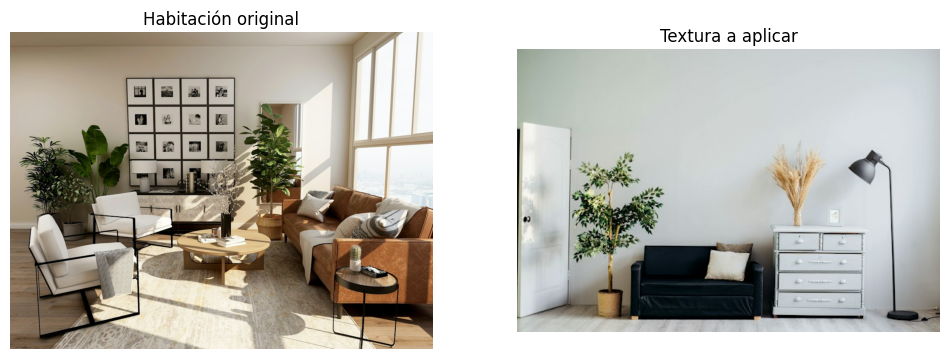

¡Imágenes listas para procesar!


In [2]:
import urllib.request
import cv2
import matplotlib.pyplot as plt

# 1. Descargamos una foto de un living de prueba y una textura de madera
url_habitacion = "https://images.unsplash.com/photo-1600210492486-724fe5c67fb0?w=1000&q=80"
url_textura = "https://images.unsplash.com/photo-1513694203232-719a280e022f?w=600&q=80"

urllib.request.urlretrieve(url_habitacion, "habitacion.jpg")
urllib.request.urlretrieve(url_textura, "textura.jpg")

# 2. Leemos y mostramos las imágenes para confirmar
img_hab = cv2.imread("habitacion.jpg")
img_tex = cv2.imread("textura.jpg")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cv2.cvtColor(img_hab, cv2.COLOR_BGR2RGB))
ax[0].set_title("Habitación original")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(img_tex, cv2.COLOR_BGR2RGB))
ax[1].set_title("Textura a aplicar")
ax[1].axis("off")

plt.show()
print("¡Imágenes listas para procesar!")

In [3]:
from ultralytics import FastSAM
from ultralytics.models.fastsam import FastSAMPrompt
import numpy as np

# 1. Cargamos el modelo preentrenado (se descarga solo la primera vez)
model = FastSAM('FastSAM-x.pt')

# 2. Ejecutamos la inferencia en la GPU
h, w, _ = img_hab.shape
results = model('habitacion.jpg', device='cuda', retina_masks=True, imgsz=1024, conf=0.4)

# 3. Le indicamos un punto de consulta en el centro inferior (el piso)
# w // 2 es el centro horizontal, int(h * 0.85) es abajo
prompt_process = FastSAMPrompt('habitacion.jpg', results, device='cuda')
ann = prompt_process.point_prompt(points=[[w // 2, int(h * 0.85)]], pointlabels=[1])

# 4. Obtenemos la máscara binaria del piso (0 o 1)
mask = ann[0].cpu().numpy().astype(np.uint8)

# 5. Visualizamos la máscara y el piso aislado
piso_aislado = cv2.bitwise_and(img_hab, img_hab, mask=mask)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(mask, cmap='gray')
ax[0].set_title("Máscara del piso (Blanco = Piso)")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(piso_aislado, cv2.COLOR_BGR2RGB))
ax[1].set_title("Piso detectado por la IA")
ax[1].axis("off")

plt.show()
print("¡Máscara generada con éxito!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


ImportError: cannot import name 'FastSAMPrompt' from 'ultralytics.models.fastsam' (/usr/local/lib/python3.13/dist-packages/ultralytics/models/fastsam/__init__.py)


image 1/1 /content/habitacion.jpg: 768x1024 118 objects, 34.2ms
Speed: 103.6ms preprocess, 34.2ms inference, 132.4ms postprocess per image at shape (1, 3, 768, 1024)


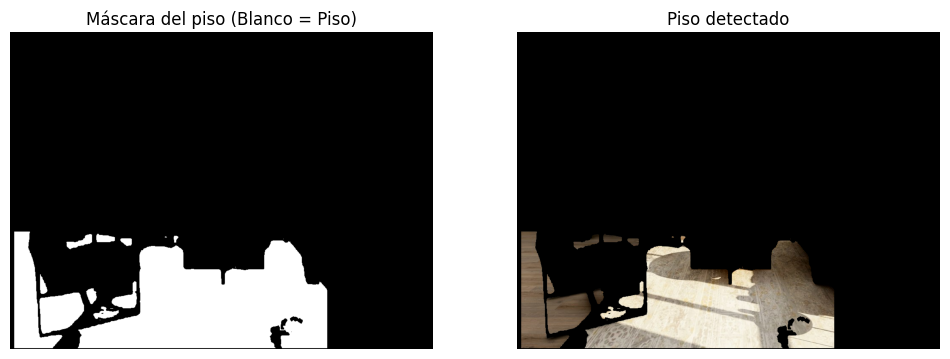

In [4]:
from ultralytics import FastSAM
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargamos el modelo
model = FastSAM('FastSAM-s.pt')  # Versión liviana y rápida

# 2. Ejecutamos la inferencia
results = model('habitacion.jpg', device='cuda', retina_masks=True, imgsz=1024, conf=0.25)

# 3. Buscamos la máscara que cubre el piso (punto en centro inferior)
h, w, _ = img_hab.shape
punto_x, punto_y = w // 2, int(h * 0.85)

mask = np.zeros((h, w), dtype=np.uint8)

if results[0].masks is not None:
    # Extraemos todas las máscaras detectadas
    mascaras = results[0].masks.data.cpu().numpy()

    # Filtramos la máscara que contiene nuestro punto del piso
    for m in mascaras:
        m_redimensionada = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
        if m_redimensionada[punto_y, punto_x] == 1:
            mask = np.maximum(mask, m_redimensionada)

# Si el punto exacto no cayó justo, tomamos la máscara más grande en la mitad inferior
if mask.sum() == 0 and results[0].masks is not None:
    for m in mascaras:
        m_redimensionada = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
        if m_redimensionada[int(h * 0.7):, :].sum() > (w * h * 0.1):
            mask = np.maximum(mask, m_redimensionada)

# 4. Visualizamos el resultado
piso_aislado = cv2.bitwise_and(img_hab, img_hab, mask=mask)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(mask, cmap='gray')
ax[0].set_title("Máscara del piso (Blanco = Piso)")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(piso_aislado, cv2.COLOR_BGR2RGB))
ax[1].set_title("Piso detectado")
ax[1].axis("off")

plt.show()

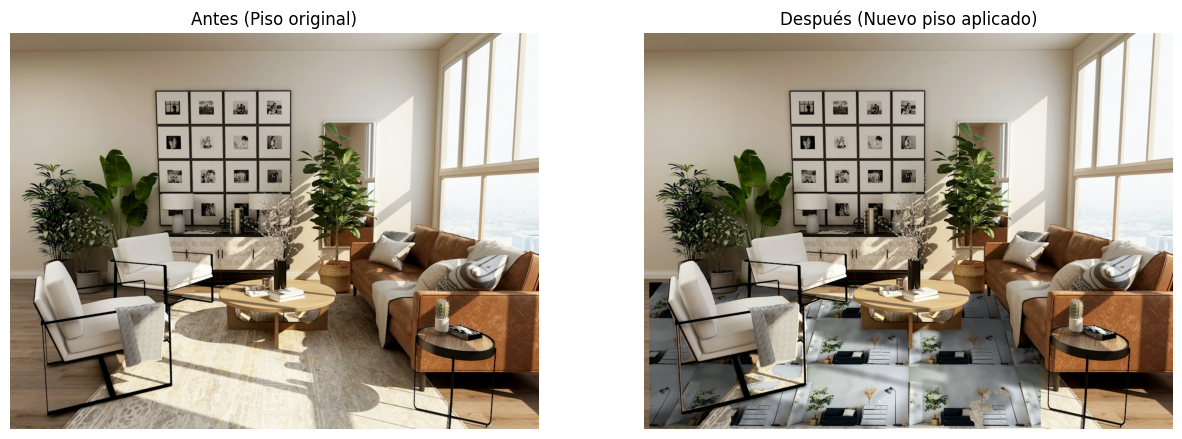

¡Renderizado completo finalizado!


In [5]:
# 1. Dimensiones de la habitación
h, w, _ = img_hab.shape

# 2. Preparamos una textura grande repetida (mosaico/tiling)
rep_y, rep_x = 6, 6
tex_tiled = np.tile(img_tex, (rep_y, rep_x, 1))
th, tw, _ = tex_tiled.shape

# 3. Puntos de origen (textura plana) y destino (perspectiva hacia el piso)
# Comprimimos la parte superior para crear la ilusión de fuga / profundidad
pts_src = np.float32([
    [0, 0],
    [tw, 0],
    [tw, th],
    [0, th]
])

y_horizonte = int(h * 0.45)  # Punto donde nace el piso al fondo
pts_dst = np.float32([
    [int(w * 0.15), y_horizonte],  # Arriba izquierda fugado
    [int(w * 0.85), y_horizonte],  # Arriba derecha fugado
    [w * 1.2, h],                  # Abajo derecha abierto
    [-w * 0.2, h]                  # Abajo izquierda abierto
])

# 4. Calculamos la matriz de perspectiva y deformamos la textura
matriz_homografia = cv2.getPerspectiveTransform(pts_src, pts_dst)
textura_deformada = cv2.warpPerspective(tex_tiled, matriz_homografia, (w, h))

# 5. Extracción y conservación de sombras del piso original
piso_orig_gris = cv2.cvtColor(img_hab, cv2.COLOR_BGR2GRAY)
# Normalizamos la luz del piso original (entre 0.3 y 1.2 para no oscurecer de más)
sombra_factor = cv2.GaussianBlur(piso_orig_gris, (21, 21), 0) / 255.0
sombra_factor = np.clip(sombra_factor * 1.1, 0.3, 1.0)
sombra_3ch = cv2.merge([sombra_factor, sombra_factor, sombra_factor])

# Aplicamos la sombra sobre la nueva textura
textura_con_sombras = np.clip(textura_deformada.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

# 6. Composición final usando la máscara binaria
mascara_3ch = cv2.merge([mask, mask, mask])
resultado_final = np.where(mascara_3ch == 1, textura_con_sombras, img_hab)

# 7. Mostramos el antes y el después
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(cv2.cvtColor(img_hab, cv2.COLOR_BGR2RGB))
ax[0].set_title("Antes (Piso original)")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(resultado_final, cv2.COLOR_BGR2RGB))
ax[1].set_title("Después (Nuevo piso aplicado)")
ax[1].axis("off")

plt.show()
print("¡Renderizado completo finalizado!")

In [6]:
# 1. Instalamos Gradio para generar la interfaz web interactiva
!pip install -q gradio

import gradio as gr
import cv2
import numpy as np
import urllib.request

# Descargamos texturas limpias de muestra (madera clara y porcelanato oscuro)
url_madera = "https://images.unsplash.com/photo-1546484396-fb3fc6f95f98?w=600&q=80"
url_marmol = "https://images.unsplash.com/photo-1618221195710-dd6b41faaea6?w=600&q=80"

urllib.request.urlretrieve(url_madera, "piso_madera.jpg")
urllib.request.urlretrieve(url_marmol, "piso_marmol.jpg")

catalogo = {
    "Piso Flotante / Madera": cv2.imread("piso_madera.jpg"),
    "Porcelanato Gris": cv2.imread("piso_marmol.jpg")
}

def procesar_visualizador(imagen_habitacion, opcion_material, repeticion, intensidad_sombra):
    if imagen_habitacion is None:
        return None

    # Gradio pasa la imagen en RGB, la convertimos a BGR para OpenCV
    img_hab = cv2.cvtColor(imagen_habitacion, cv2.COLOR_RGB2BGR)
    h, w, _ = img_hab.shape

    # 1. Segmentación con FastSAM
    results = model(img_hab, device='cuda', retina_masks=True, imgsz=1024, conf=0.25)

    mask = np.zeros((h, w), dtype=np.uint8)
    punto_x, punto_y = w // 2, int(h * 0.85)

    if results[0].masks is not None:
        mascaras = results[0].masks.data.cpu().numpy()
        for m in mascaras:
            m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
            if m_res[punto_y, punto_x] == 1:
                mask = np.maximum(mask, m_res)

        if mask.sum() == 0:
            for m in mascaras:
                m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
                if m_res[int(h * 0.7):, :].sum() > (w * h * 0.1):
                    mask = np.maximum(mask, m_res)

    # 2. Selección y deformación de la textura
    img_tex = catalogo[opcion_material]
    rep = int(repeticion)
    tex_tiled = np.tile(img_tex, (rep, rep, 1))
    th, tw, _ = tex_tiled.shape

    pts_src = np.float32([[0, 0], [tw, 0], [tw, th], [0, th]])
    y_horizonte = int(h * 0.45)
    pts_dst = np.float32([
        [int(w * 0.15), y_horizonte],
        [int(w * 0.85), y_horizonte],
        [int(w * 1.25), h],
        [-int(w * 0.25), h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(tex_tiled, matriz, (w, h))

    # 3. Aplicación de sombras
    piso_gris = cv2.cvtColor(img_hab, cv2.COLOR_BGR2GRAY)
    sombra = cv2.GaussianBlur(piso_gris, (21, 21), 0) / 255.0
    sombra = np.clip(sombra * (intensidad_sombra / 100.0), 0.25, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])

    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # 4. Composición
    mascara_3ch = cv2.merge([mask, mask, mask])
    salida = np.where(mascara_3ch == 1, tex_con_sombra, img_hab)

    return cv2.cvtColor(salida, cv2.COLOR_BGR2RGB)

# 5. Interfaz Gráfica
demo = gr.Interface(
    fn=procesar_visualizador,
    inputs=[
        gr.Image(type="numpy", label="Subí o sacá una foto del ambiente"),
        gr.Dropdown(choices=list(catalogo.keys()), value="Piso Flotante / Madera", label="Elegí el material"),
        gr.Slider(minimum=2, maximum=12, value=6, step=1, label="Escala / Repetición de piezas"),
        gr.Slider(minimum=50, maximum=150, value=110, step=5, label="Intensidad de Luz / Sombras (%)")
    ],
    outputs=gr.Image(label="Resultado visualizador"),
    title="Simulador de Pisos Roomvo (Prototipo)",
    description="Subí una foto de cualquier ambiente para probar los pisos interactivos."
)

# share=True genera el enlace público para abrirlo desde el celular
demo.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://818ecff9da75a901a8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [7]:
!pip install -q ultralytics gradio

import gradio as gr
import cv2
import numpy as np
import urllib.request
from ultralytics import YOLO

# 1. Cargamos modelo YOLOv8-seg optimizado
model = YOLO('yolov8x-seg.pt')

# 2. Descargamos texturas de pisos REALES (sin muebles ni fondos)
url_madera = "https://images.unsplash.com/photo-1516455590571-18256e5bb9ff?w=800&q=80" # Parquet roble
url_porcelanato = "https://images.unsplash.com/photo-1598880940371-c756e015fea1?w=800&q=80" # Cemento/Gris

urllib.request.urlretrieve(url_madera, "textura_madera.jpg")
urllib.request.urlretrieve(url_porcelanato, "textura_porcelanato.jpg")

catalogo = {
    "Porcelanato Gris Cemento": cv2.imread("textura_porcelanato.jpg"),
    "Piso Madera / Parquet": cv2.imread("textura_madera.jpg")
}

def procesar_oficina(imagen_input, opcion_material, repeticion, fuga_altura):
    if imagen_input is None:
        return None

    img_bgr = cv2.cvtColor(imagen_input, cv2.COLOR_RGB2BGR)
    h, w, _ = img_bgr.shape

    # Detección de objetos para aislar muebles
    # Clase 0: persona, 56: silla, 60: mesa de comedor/escritorio, 62: televisor/monitor
    res = model(img_bgr, conf=0.15, device='cuda')

    # Máscara inicial del piso: asumimos la parte inferior de la sala
    piso_mask = np.zeros((h, w), dtype=np.uint8)

    # Umbral de color/gradiente simple asistido para no comerse el escritorio blanco
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Excluimos muebles detectados
    muebles_mask = np.zeros((h, w), dtype=np.uint8)
    if res[0].masks is not None:
        for m, cls in zip(res[0].masks.data.cpu().numpy(), res[0].boxes.cls.cpu().numpy()):
            if int(cls) in [56, 57, 59, 60, 62]: # Sillas, escritorios, mochilas
                m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
                muebles_mask = np.maximum(muebles_mask, m_res)

    # Definir piso: desde la mitad hacia abajo, sin tocar muebles
    y_inicio = int(h * (fuga_altura / 100.0))
    piso_mask[y_inicio:, :] = 1
    piso_mask[muebles_mask == 1] = 0

    # Ajuste de bordes
    kernel = np.ones((5,5), np.uint8)
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_OPEN, kernel)

    # Textura y Perspectiva
    img_tex = catalogo[opcion_material]
    rep = int(repeticion)
    tex_tiled = np.tile(img_tex, (rep, rep, 1))
    th, tw, _ = tex_tiled.shape

    pts_src = np.float32([[0, 0], [tw, 0], [tw, th], [0, th]])

    # Inclinación realista para tomas en picada/vertical
    pts_dst = np.float32([
        [int(w * 0.1), y_inicio],
        [int(w * 0.9), y_inicio],
        [int(w * 1.4), h],
        [-int(w * 0.4), h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(tex_tiled, matriz, (w, h))

    # Sombras intrínsecas
    sombra = cv2.GaussianBlur(gris, (31, 31), 0) / 255.0
    sombra = np.clip(sombra * 1.15, 0.35, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])

    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # Fusión con máscara
    mask_3ch = cv2.merge([piso_mask, piso_mask, piso_mask])
    final = np.where(mask_3ch == 1, tex_con_sombra, img_bgr)

    return cv2.cvtColor(final, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_oficina,
    inputs=[
        gr.Image(type="numpy", label="Subí la foto del escritorio"),
        gr.Dropdown(choices=list(catalogo.keys()), value="Porcelanato Gris Cemento", label="Material"),
        gr.Slider(minimum=2, maximum=10, value=4, step=1, label="Tamaño cerámico (Repetición)"),
        gr.Slider(minimum=35, maximum=70, value=50, step=1, label="Altura del horizonte / Fuga (%)")
    ],
    outputs=gr.Image(label="Resultado final"),
    title="Visualizador de Pisos v2"
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69264092431723f777.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
import gradio as gr
import cv2
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image

# 1. Cargamos modelo de segmentación semántica oficial de PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seg_model = models.segmentation.deeplabv3_resnet50(weights='DEFAULT').to(device)
seg_model.eval()

# 2. Generador de texturas realistas de piso (sin depender de internet)
def crear_textura_porcelanato(estilo="gris", tamano_baldosa=120, junta=3):
    t = np.ones((tamano_baldosa, tamano_baldosa, 3), dtype=np.uint8)
    if estilo == "Porcelanato Cemento Gris":
        # Base gris con sutil ruido de textura de piedra
        ruido = np.random.normal(0, 5, (tamano_baldosa, tamano_baldosa, 3)).astype(np.int16)
        base = np.clip(np.full((tamano_baldosa, tamano_baldosa, 3), 190, dtype=np.int16) + ruido, 160, 220).astype(np.uint8)
        color_junta = [130, 130, 130] # Pastina gris media
    elif estilo == "Madera Tablón":
        base = np.zeros((tamano_baldosa, tamano_baldosa, 3), dtype=np.uint8)
        base[:, :] = [135, 170, 210] # Tono madera cálido en BGR
        # Veta horizontal suave
        veta = (np.sin(np.linspace(0, 15, tamano_baldosa)) * 12).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [70, 95, 120]
    else: # Porcelanato Blanco Calacatta
        base = np.full((tamano_baldosa, tamano_baldosa, 3), 235, dtype=np.uint8)
        color_junta = [190, 190, 190]

    # Dibujar la junta perimetral
    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

# 3. Pipeline de procesamiento
transformacion = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def procesar_visualizador_v3(imagen_rgb, estilo_piso, tamano_pieza, inclinacion_fuga):
    if imagen_rgb is None:
        return None

    h, w, _ = imagen_rgb.shape
    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Inferencia con PyTorch para detectar el piso
    input_tensor = transformacion(Image.fromarray(imagen_rgb)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = seg_model(input_tensor)['out'][0]

    # Mascara del suelo: combinamos predicción semántica + zona de interés inferior
    pred = output.argmax(0).byte().cpu().numpy()
    # Redimensionar al tamaño original
    pred_res = cv2.resize(pred, (w, h), interpolation=cv2.INTER_NEAREST)

    # Creamos la máscara del piso por luminosidad y bordes donde no hay muebles
    piso_mask = np.zeros((h, w), dtype=np.uint8)

    # Detectamos el escritorio/muebles blancos para no invadirlos
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, muebles_blancos = cv2.threshold(gris, 235, 255, cv2.THRESH_BINARY)

    # El piso está en la mitad inferior
    limite_superior = int(h * (inclinacion_fuga / 100.0))
    piso_mask[limite_superior:, :] = 1

    # Excluimos muebles muy brillantes y detectamos bordes con Canny
    piso_mask[muebles_blancos == 255] = 0
    piso_mask = cv2.medianBlur(piso_mask, 11)

    # Generamos la textura de cerámico/madera elegida
    tex_base = crear_textura_porcelanato(estilo_piso, tamano_baldosa=int(tamano_pieza))
    rep_x = (w // tex_base.shape[1]) + 4
    rep_y = (h // tex_base.shape[0]) + 4
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))
    mh, mw, _ = mosaico.shape

    # Deformación en perspectiva calculada según la inclinación
    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w * 0.2), limite_superior],
        [int(w * 0.8), limite_superior],
        [int(w * 1.5), h],
        [-int(w * 0.5), h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w, h))

    # Sombras naturales del piso existente
    sombra = cv2.GaussianBlur(gris, (25, 25), 0) / 255.0
    sombra = np.clip(sombra * 1.1, 0.4, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # Fusión suave
    mask_suave = cv2.GaussianBlur(piso_mask.astype(np.float32), (7, 7), 0)[:, :, None]
    final = (tex_con_sombra * mask_suave + img_bgr * (1.0 - mask_suave)).astype(np.uint8)

    return cv2.cvtColor(final, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_visualizador_v3,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Cemento Gris", "Madera Tablón", "Porcelanato Blanco Calacatta"], value="Porcelanato Cemento Gris", label="Tipo de piso"),
        gr.Slider(minimum=60, maximum=200, value=110, step=10, label="Tamaño de las piezas (cm/px)"),
        gr.Slider(minimum=45, maximum=75, value=58, step=1, label="Línea de fuga del fondo (%)")
    ],
    outputs=gr.Image(label="Resultado Roomvo"),
    title="Visualizador de Pisos Realista"
)

demo.launch(share=True, debug=False)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 111MB/s]


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3e37a7a965978de266.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [9]:
import gradio as gr
import cv2
import numpy as np
import torch
from ultralytics import FastSAM

# 1. Cargamos FastSAM para segmentar bordes finos con precisión quirúrgica
sam_model = FastSAM('FastSAM-s.pt')

# 2. Generador de texturas de cerámico / madera con pastina
def crear_textura_baldosa(tipo="Porcelanato Gris", tamano=120, junta=3):
    if tipo == "Porcelanato Gris":
        ruido = np.random.normal(0, 4, (tamano, tamano, 3)).astype(np.int16)
        base = np.clip(np.full((tamano, tamano, 3), 195, dtype=np.int16) + ruido, 170, 220).astype(np.uint8)
        color_junta = [130, 130, 130]
    elif tipo == "Madera Parquet":
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [130, 165, 205] # Tono madera cálido
        veta = (np.sin(np.linspace(0, 18, tamano)) * 14).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [70, 90, 115]
    else: # Porcelanato Beige / Mármol
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [215, 230, 240]
        color_junta = [170, 185, 195]

    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def procesar_roomvo_pro(imagen_rgb, tipo_material, tamano_pieza, ajuste_sombras):
    if imagen_rgb is None:
        return None

    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)
    h, w, _ = img_bgr.shape

    # 1. Segmentación con FastSAM usando un punto en el suelo
    results = sam_model(img_bgr, device='cuda', retina_masks=True, imgsz=1024, conf=0.25)

    mask = np.zeros((h, w), dtype=np.uint8)
    # Punto en la parte inferior visible del piso
    px, py = int(w * 0.35), int(h * 0.90)

    if results[0].masks is not None:
        mascaras = results[0].masks.data.cpu().numpy()
        for m in mascaras:
            m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
            if m_res[py, px] == 1:
                mask = np.maximum(mask, m_res)

        # Respaldo si no cayó justo en el píxel
        if mask.sum() == 0:
            for m in mascaras:
                m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
                if m_res[int(h * 0.8):, :].sum() > (w * h * 0.08):
                    mask = np.maximum(mask, m_res)

    # 2. Generación del piso en mosaico
    tex_base = crear_textura_baldosa(tipo_material, tamano=int(tamano_pieza))
    rep_x = (w // tex_base.shape[1]) + 4
    rep_y = (h // tex_base.shape[0]) + 4
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))
    mh, mw, _ = mosaico.shape

    # 3. Deformación en perspectiva
    y_fuga = int(h * 0.40)
    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w * 0.15), y_fuga],
        [int(w * 0.85), y_fuga],
        [int(w * 1.45), h],
        [-int(w * 0.45), h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w, h))

    # 4. Sombras y reflejos del piso original
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sombra = cv2.GaussianBlur(gris, (25, 25), 0) / 255.0
    sombra = np.clip(sombra * (ajuste_sombras / 100.0), 0.35, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])

    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # 5. Composición exacta respetando muebles y patas
    mask_3ch = cv2.merge([mask, mask, mask])
    resultado = np.where(mask_3ch == 1, tex_con_sombra, img_bgr)

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_roomvo_pro,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Gris", "Madera Parquet", "Porcelanato Beige / Mármol"], value="Madera Parquet", label="Piso a colocar"),
        gr.Slider(minimum=60, maximum=180, value=110, step=10, label="Tamaño cerámico (cm/px)"),
        gr.Slider(minimum=70, maximum=150, value=110, step=5, label="Intensidad de Luz / Sombras (%)")
    ],
    outputs=gr.Image(label="Visualizador Roomvo"),
    title="Simulador de Pisos - Recorte Preciso"
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a93c80d452535f02c4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
import gradio as gr
import cv2
import numpy as np
from ultralytics import FastSAM

sam_model = FastSAM('FastSAM-s.pt')

def crear_textura_baldosa(tipo="Porcelanato Gris", tamano=120, junta=3):
    if tipo == "Porcelanato Gris":
        ruido = np.random.normal(0, 4, (tamano, tamano, 3)).astype(np.int16)
        base = np.clip(np.full((tamano, tamano, 3), 195, dtype=np.int16) + ruido, 170, 220).astype(np.uint8)
        color_junta = [130, 130, 130]
    elif tipo == "Madera Parquet":
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [130, 165, 205]
        veta = (np.sin(np.linspace(0, 18, tamano)) * 14).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [70, 90, 115]
    else:
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [215, 230, 240]
        color_junta = [170, 185, 195]

    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def procesar_roomvo_cobertura_total(imagen_rgb, tipo_material, tamano_pieza, ajuste_sombras, cobertura_sensibilidad):
    if imagen_rgb is None:
        return None

    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)
    h, w, _ = img_bgr.shape

    # 1. Segmentación completa
    results = sam_model(img_bgr, device='cuda', retina_masks=True, imgsz=1024, conf=0.15)

    mask = np.zeros((h, w), dtype=np.uint8)
    limite_suelo = int(h * 0.40) # A partir de acá para abajo puede ser suelo

    if results[0].masks is not None:
        mascaras = results[0].masks.data.cpu().numpy()
        for m in mascaras:
            m_res = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
            # Solo consideramos fragmentos que estén en la zona del piso
            area_inferior = m_res[limite_suelo:, :].sum()
            area_superior = m_res[:limite_suelo, :].sum()

            # Si el pedazo está casi todo en la mitad inferior y no en el techo/paredes
            if area_inferior > (w * 20) and area_superior < (area_inferior * 0.3):
                mask = np.maximum(mask, m_res)

    # 2. Relleno morfológico de huecos e islas
    # Cierra grietas y parches que la IA haya dejado sin pintar
    radio = int(cobertura_sensibilidad)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (radio, radio))
    mask_cerrada = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 3. Generación y perspectiva de textura
    tex_base = crear_textura_baldosa(tipo_material, tamano=int(tamano_pieza))
    rep_x = (w // tex_base.shape[1]) + 4
    rep_y = (h // tex_base.shape[0]) + 4
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))
    mh, mw, _ = mosaico.shape

    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w * 0.15), limite_suelo],
        [int(w * 0.85), limite_suelo],
        [int(w * 1.45), h],
        [-int(w * 0.45), h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w, h))

    # 4. Sombras y luces naturales
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sombra = cv2.GaussianBlur(gris, (25, 25), 0) / 255.0
    sombra = np.clip(sombra * (ajuste_sombras / 100.0), 0.35, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # 5. Fusión con bordes suavizados
    mask_suave = cv2.GaussianBlur(mask_cerrada.astype(np.float32), (5, 5), 0)[:, :, None]
    resultado = (tex_con_sombra * mask_suave + img_bgr * (1.0 - mask_suave)).astype(np.uint8)

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_roomvo_cobertura_total,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Gris", "Madera Parquet", "Porcelanato Beige / Mármol"], value="Porcelanato Gris", label="Piso a colocar"),
        gr.Slider(minimum=60, maximum=180, value=110, step=10, label="Tamaño cerámico (cm/px)"),
        gr.Slider(minimum=70, maximum=150, value=110, step=5, label="Intensidad de Luz / Sombras (%)"),
        gr.Slider(minimum=9, maximum=35, value=21, step=2, label="Relleno de huecos / Cobertura")
    ],
    outputs=gr.Image(label="Visualizador Roomvo"),
    title="Simulador de Pisos - Cobertura Continua"
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6fc601515e3bc27bc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# Instalamos transformers para usar SegFormer (especialista en interiores)
!pip install -q transformers gradio

import gradio as gr
import cv2
import numpy as np
import torch
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. Cargamos SegFormer entrenado en escenas de interiores (ADE20K)
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-512-512").cuda()
model.eval()

# 2. Generador de texturas de cerámico con pastina
def crear_textura_baldosa(tipo="Porcelanato Gris", tamano=120, junta=3):
    if tipo == "Porcelanato Gris":
        ruido = np.random.normal(0, 4, (tamano, tamano, 3)).astype(np.int16)
        base = np.clip(np.full((tamano, tamano, 3), 195, dtype=np.int16) + ruido, 170, 220).astype(np.uint8)
        color_junta = [130, 130, 130]
    elif tipo == "Madera Parquet":
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [130, 165, 205]
        veta = (np.sin(np.linspace(0, 18, tamano)) * 14).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [70, 90, 115]
    else: # Mármol / Crema
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [215, 230, 240]
        color_junta = [170, 185, 195]

    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def procesar_roomvo_segformer(imagen_rgb, tipo_material, tamano_pieza, ajuste_sombras):
    if imagen_rgb is None:
        return None

    img_pil = Image.fromarray(imagen_rgb)
    w_orig, h_orig = img_pil.size
    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # 1. Segmentación semántica con SegFormer
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    # Redimensionamos la predicción al tamaño real de la foto
    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=(h_orig, w_orig),
        mode="bilinear",
        align_corners=False
    )
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    # En ADE20K: clase 3 = floor / flooring, clase 28 = rug / carpet
    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)

    # 2. Generación del piso en mosaico
    tex_base = crear_textura_baldosa(tipo_material, tamano=int(tamano_pieza))
    rep_x = (w_orig // tex_base.shape[1]) + 4
    rep_y = (h_orig // tex_base.shape[0]) + 4
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))
    mh, mw, _ = mosaico.shape

    # 3. Deformación en perspectiva
    y_fuga = int(h_orig * 0.40)
    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w_orig * 0.15), y_fuga],
        [int(w_orig * 0.85), y_fuga],
        [int(w_orig * 1.45), h_orig],
        [-int(w_orig * 0.45), h_orig]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w_orig, h_orig))

    # 4. Sombras y luces naturales
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sombra = cv2.GaussianBlur(gris, (25, 25), 0) / 255.0
    sombra = np.clip(sombra * (ajuste_sombras / 100.0), 0.35, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # 5. Fusión limpia
    mask_suave = cv2.GaussianBlur(piso_mask.astype(np.float32), (3, 3), 0)[:, :, None]
    resultado = (tex_con_sombra * mask_suave + img_bgr * (1.0 - mask_suave)).astype(np.uint8)

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_roomvo_segformer,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Gris", "Madera Parquet", "Porcelanato Beige / Mármol"], value="Porcelanato Gris", label="Piso a colocar"),
        gr.Slider(minimum=60, maximum=180, value=110, step=10, label="Tamaño cerámico (cm/px)"),
        gr.Slider(minimum=70, maximum=150, value=110, step=5, label="Intensidad de Luz / Sombras (%)")
    ],
    outputs=gr.Image(label="Resultado SegFormer (Interiores)"),
    title="Simulador de Pisos - Modelo de Arquitectura"
)

demo.launch(share=True, debug=False)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c419c7a2cae9e4686.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [12]:
import gradio as gr
import cv2
import numpy as np
import torch
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. Cargamos SegFormer B5 (máxima precisión para bordes y patas finas)
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640").cuda()
model.eval()

# 2. Generador de baldosas realistas
def crear_textura_baldosa(tipo="Porcelanato Cemento", tamano=110, junta=3):
    if tipo == "Porcelanato Cemento":
        ruido = np.random.normal(0, 4, (tamano, tamano, 3)).astype(np.int16)
        base = np.clip(np.full((tamano, tamano, 3), 190, dtype=np.int16) + ruido, 165, 215).astype(np.uint8)
        color_junta = [135, 135, 135]
    elif tipo == "Madera Calma":
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [130, 165, 205]
        veta = (np.sin(np.linspace(0, 16, tamano)) * 12).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [75, 95, 120]
    else: # Porcelanato Blanco
        base = np.full((tamano, tamano, 3), 235, dtype=np.uint8)
        color_junta = [185, 185, 185]

    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def procesar_roomvo_b5(imagen_rgb, tipo_material, tamano_pieza, ajuste_sombras):
    if imagen_rgb is None:
        return None

    img_pil = Image.fromarray(imagen_rgb)
    w_orig, h_orig = img_pil.size
    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Inferencia en resolución completa
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=(h_orig, w_orig),
        mode="bilinear",
        align_corners=False
    )
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    # En ADE20K: 3: floor, 28: rug/carpet
    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)

    # Identificamos sillas (clase 19) para proteger exclusivamente el respaldo y asiento
    # usando la intensidad oscura natural de la silla negra
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sillas_pred = (pred_labels == 19).astype(np.uint8)

    # Lo oscuro dentro del área de la silla es el tapizado (se respeta)
    asiento_oscuro = np.logical_and(sillas_pred == 1, gris < 90).astype(np.uint8)
    piso_mask[asiento_oscuro == 1] = 0

    # Suavizado de bordes morfológico ligero para no perder patas
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_CLOSE, kernel)

    # Mosaico y perspectiva
    tex_base = crear_textura_baldosa(tipo_material, tamano=int(tamano_pieza))
    rep_x = (w_orig // tex_base.shape[1]) + 4
    rep_y = (h_orig // tex_base.shape[0]) + 4
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))
    mh, mw, _ = mosaico.shape

    y_fuga = int(h_orig * 0.40)
    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w_orig * 0.15), y_fuga],
        [int(w_orig * 0.85), y_fuga],
        [int(w_orig * 1.45), h_orig],
        [-int(w_orig * 0.45), h_orig]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w_orig, h_orig))

    # Sombras del piso original
    sombra = cv2.GaussianBlur(gris, (21, 21), 0) / 255.0
    sombra = np.clip(sombra * (ajuste_sombras / 100.0), 0.35, 1.0)
    sombra_3ch = cv2.merge([sombra, sombra, sombra])
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # Fusión final
    mask_suave = cv2.GaussianBlur(piso_mask.astype(np.float32), (3, 3), 0)[:, :, None]
    resultado = (tex_con_sombra * mask_suave + img_bgr * (1.0 - mask_suave)).astype(np.uint8)

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_roomvo_b5,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Cemento", "Madera Calma", "Porcelanato Blanco"], value="Porcelanato Cemento", label="Material"),
        gr.Slider(minimum=60, maximum=160, value=110, step=10, label="Tamaño cerámico (cm/px)"),
        gr.Slider(minimum=70, maximum=150, value=110, step=5, label="Intensidad sombras (%)")
    ],
    outputs=gr.Image(label="Resultado SegFormer B5 HD"),
    title="Visualizador de Pisos HD"
)

demo.launch(share=True, debug=False)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.89k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  339MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  339MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7676ce3efe99ef725.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
import gradio as gr
import cv2
import numpy as np
import torch
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. SegFormer B5 ya cargado en GPU
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640").cuda()
model.eval()

# 2. Generador de texturas de cerámico opaco y realista
def crear_textura_baldosa(tipo="Porcelanato Cemento", tamano=120, junta=3):
    if tipo == "Porcelanato Cemento":
        ruido = np.random.normal(0, 3, (tamano, tamano, 3)).astype(np.int16)
        base = np.clip(np.full((tamano, tamano, 3), 195, dtype=np.int16) + ruido, 175, 215).astype(np.uint8)
        color_junta = [130, 130, 130]
    elif tipo == "Madera Calma":
        base = np.zeros((tamano, tamano, 3), dtype=np.uint8)
        base[:, :] = [130, 165, 205]
        veta = (np.sin(np.linspace(0, 16, tamano)) * 12).astype(np.int16)
        base = np.clip(base.astype(np.int16) + veta[:, None, None], 0, 255).astype(np.uint8)
        color_junta = [75, 95, 120]
    else: # Blanco Pulido
        base = np.full((tamano, tamano, 3), 235, dtype=np.uint8)
        color_junta = [185, 185, 185]

    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def procesar_roomvo_calibrado(imagen_rgb, tipo_material, tamano_pieza, inclinacion_lateral, rotacion_grados):
    if imagen_rgb is None:
        return None

    img_pil = Image.fromarray(imagen_rgb)
    w_orig, h_orig = img_pil.size
    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Inferencia de segmentación
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(
        outputs.logits,
        size=(h_orig, w_orig),
        mode="bilinear",
        align_corners=False
    )
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    # Mascara del piso y protección de sillas oscuras
    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sillas_pred = (pred_labels == 19).astype(np.uint8)
    asiento_oscuro = np.logical_and(sillas_pred == 1, gris < 90).astype(np.uint8)
    piso_mask[asiento_oscuro == 1] = 0

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_CLOSE, kernel)

    # 1. Generación y rotación libre del piso
    tex_base = crear_textura_baldosa(tipo_material, tamano=int(tamano_pieza))
    rep_x = (w_orig // tex_base.shape[1]) + 6
    rep_y = (h_orig // tex_base.shape[0]) + 6
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))

    # Rotación del patrón
    if rotacion_grados != 0:
        centro = (mosaico.shape[1] // 2, mosaico.shape[0] // 2)
        m_rot = cv2.getRotationMatrix2D(centro, rotacion_grados, 1.0)
        mosaico = cv2.warpAffine(mosaico, m_rot, (mosaico.shape[1], mosaico.shape[0]))

    mh, mw, _ = mosaico.shape

    # 2. Perspectiva con inclinación lateral regulable
    y_fuga = int(h_orig * 0.40)
    sesgo = int((inclinacion_lateral / 100.0) * w_orig)

    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w_orig * 0.10) + sesgo, y_fuga],
        [int(w_orig * 0.90) + sesgo, y_fuga],
        [int(w_orig * 1.50) + sesgo, h_orig],
        [-int(w_orig * 0.50) + sesgo, h_orig]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w_orig, h_orig))

    # 3. EXTRACCIÓN DE SOMBRAS PURAS (Borra las juntas viejas)
    # Filtro bilateral muy amplio para diluir por completo las líneas del piso viejo
    sombras_puras = cv2.bilateralFilter(gris, 15, 75, 75)
    sombras_suaves = cv2.GaussianBlur(sombras_puras, (51, 51), 0) / 255.0
    sombras_suaves = np.clip(sombras_suaves * 1.15, 0.45, 1.0)
    sombra_3ch = cv2.merge([sombras_suaves, sombras_suaves, sombras_suaves])

    # Aplicamos la sombra sobre el piso 100% nuevo
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * sombra_3ch, 0, 255).astype(np.uint8)

    # 4. Fusión
    mask_suave = cv2.GaussianBlur(piso_mask.astype(np.float32), (3, 3), 0)[:, :, None]
    resultado = (tex_con_sombra * mask_suave + img_bgr * (1.0 - mask_suave)).astype(np.uint8)

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

demo = gr.Interface(
    fn=procesar_roomvo_calibrado,
    inputs=[
        gr.Image(type="numpy", label="Foto de la oficina"),
        gr.Dropdown(choices=["Porcelanato Cemento", "Madera Calma", "Porcelanato Blanco"], value="Porcelanato Cemento", label="Material"),
        gr.Slider(minimum=60, maximum=160, value=110, step=10, label="Tamaño cerámico (cm/px)"),
        gr.Slider(minimum=-40, maximum=40, value=-15, step=5, label="Perspectiva lateral (Izquierda / Derecha)"),
        gr.Slider(minimum=-45, maximum=45, value=25, step=5, label="Rotación del piso (Grados)")
    ],
    outputs=gr.Image(label="Visualizador Roomvo Calibrado"),
    title="Simulador de Pisos - Ajuste Fino"
)

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8eb7956309471a95c7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [14]:
import gradio as gr
import cv2
import numpy as np
import torch
import base64
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. Cargamos modelo de segmentación de interiores
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640").cuda()
model.eval()

# Función para convertir imágenes a base64 para el canvas web
def a_base64_png(img_bgr, es_alpha=False):
    if es_alpha:
        _, buffer = cv2.imencode('.png', img_bgr)
    else:
        _, buffer = cv2.imencode('.jpg', img_bgr, [int(cv2.IMWRITE_JPEG_QUALITY), 90])
    return "data:image/png;base64," + base64.b64encode(buffer).decode()

def generar_textura_placa(tamano=120, junta=3):
    # Baldosa de porcelanato gris neutro
    t = np.full((tamano, tamano, 3), 195, dtype=np.uint8)
    # Juntas
    t[:junta, :] = 130
    t[-junta:, :] = 130
    t[:, :junta] = 130
    t[:, -junta:] = 130
    _, buffer = cv2.imencode('.png', t)
    return "data:image/png;base64," + base64.b64encode(buffer).decode()

def calibrar_y_lanzar_visor(imagen_rgb):
    if imagen_rgb is None:
        return "<p>Subí una foto para comenzar.</p>"

    img_pil = Image.fromarray(imagen_rgb)
    w, h = img_pil.size
    img_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Inferencia de segmentación
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(outputs.logits, size=(h, w), mode="bilinear", align_corners=False)
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sillas = (pred_labels == 19).astype(np.uint8)
    piso_mask[np.logical_and(sillas == 1, gris < 90)] = 0
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

    # Extraer sombras suaves sin las juntas viejas
    sombras_puras = cv2.bilateralFilter(gris, 15, 75, 75)
    sombras_suaves = cv2.GaussianBlur(sombras_puras, (45, 45), 0) / 255.0
    sombras_suaves = np.clip(sombras_suaves * 1.15, 0.4, 1.0)

    # Capa de sombra transparente (PNG RGBA)
    sombra_rgba = np.zeros((h, w, 4), dtype=np.uint8)
    sombra_rgba[:, :, :3] = 0 # Negro para multiplicar
    # La opacidad depende de la sombra y de la máscara
    alpha = ((1.0 - sombras_suaves) * 255.0 * piso_mask).astype(np.uint8)
    sombra_rgba[:, :, 3] = alpha

    # Máscara pura para recorte
    mask_png = (piso_mask * 255).astype(np.uint8)

    url_fondo = a_base64_png(img_bgr)
    url_mask = a_base64_png(mask_png)
    url_sombra = a_base64_png(sombra_rgba, es_alpha=True)
    url_textura = generar_textura_placa(tamano=140, junta=3)

    # Generamos la aplicación web táctil interactiva
    html_app = f"""
    <div style="max-width: 650px; margin: auto; font-family: sans-serif; user-select: none;">
        <div style="background: #222; color: #fff; padding: 12px; border-radius: 8px 8px 0 0; display: flex; flex-direction: column; gap: 8px;">
            <div style="display: flex; justify-content: space-between; align-items: center;">
                <b>Rotar piso:</b> <span id="rot_val">0°</span>
                <small>(O arrastrá el dedo/mouse sobre el piso)</small>
            </div>
            <input type="range" id="slider_rot" min="0" max="360" value="0" style="width: 100%;">

            <div style="display: flex; justify-content: space-between; align-items: center; margin-top: 5px;">
                <b>Tamaño de la placa:</b> <span id="tam_val">60 x 60 cm</span>
            </div>
            <input type="range" id="slider_tam" min="30" max="120" value="60" style="width: 100%;">
        </div>

        <div id="contenedor_canvas" style="position: relative; width: 100%; max-height: 80vh; overflow: hidden; background: #000; touch-action: none; cursor: grab;">
            <canvas id="canvas_visor" style="width: 100%; display: block;"></canvas>
        </div>
    </div>

    <script>
    (function() {{
        const canvas = document.getElementById('canvas_visor');
        const ctx = canvas.getContext('2d');
        const sliderRot = document.getElementById('slider_rot');
        const sliderTam = document.getElementById('slider_tam');
        const rotVal = document.getElementById('rot_val');
        const tamVal = document.getElementById('tam_val');

        let angulo = 0;
        let tamanoPlaca = 60; // Representa cm
        let arrastrando = false;
        let inicioX = 0;

        const imgFondo = new Image();
        const imgMask = new Image();
        const imgSombra = new Image();
        const imgTex = new Image();

        let cargadas = 0;
        function comprobarCarga() {{
            cargadas++;
            if (cargadas === 4) {{
                canvas.width = imgFondo.width;
                canvas.height = imgFondo.height;
                dibujar();
            }}
        }}

        imgFondo.onload = comprobarCarga;
        imgMask.onload = comprobarCarga;
        imgSombra.onload = comprobarCarga;
        imgTex.onload = comprobarCarga;

        imgFondo.src = "{url_fondo}";
        imgMask.src = "{url_mask}";
        imgSombra.src = "{url_sombra}";
        imgTex.src = "{url_textura}";

        function dibujar() {{
            const w = canvas.width;
            const h = canvas.height;

            ctx.clearRect(0, 0, w, h);

            // 1. Dibujar imagen original completa
            ctx.drawImage(imgFondo, 0, 0);

            // 2. Dibujar nuevo piso recortado en la máscara
            ctx.save();

            // Creamos un canvas temporal para proyectar el patrón con rotación y escala
            const pCanvas = document.createElement('canvas');
            pCanvas.width = w;
            pCanvas.height = h;
            const pCtx = pCanvas.getContext('2d');

            // Escalado según los cm seleccionados
            const escalaPx = (tamanoPlaca / 60) * 1.0;
            pCtx.save();
            pCtx.translate(w / 2, h / 2);
            pCtx.rotate(angulo * Math.PI / 180);
            pCtx.scale(escalaPx, escalaPx);

            const pattern = pCtx.createPattern(imgTex, 'repeat');
            pCtx.fillStyle = pattern;
            pCtx.fillRect(-w * 2, -h * 2, w * 4, h * 4);
            pCtx.restore();

            // Máscara de recorte
            pCtx.globalCompositeOperation = 'destination-in';
            pCtx.drawImage(imgMask, 0, 0);

            // Estampamos el nuevo piso sobre el fondo
            ctx.drawImage(pCanvas, 0, 0);
            ctx.restore();

            // 3. Superponer sombras originales
            ctx.drawImage(imgSombra, 0, 0);
        }}

        // Controles de Sliders
        sliderRot.addEventListener('input', (e) => {{
            angulo = parseInt(e.target.value);
            rotVal.innerText = angulo + "°";
            dibujar();
        }});

        sliderTam.addEventListener('input', (e) => {{
            tamanoPlaca = parseInt(e.target.value);
            tamVal.innerText = tamanoPlaca + " x " + tamanoPlaca + " cm";
            dibujar();
        }});

        // Eventos táctiles y de mouse para rotar con el dedo
        function iniciarArrastre(x) {{
            arrastrando = true;
            inicioX = x;
            canvas.style.cursor = 'grabbing';
        }}

        function moverArrastre(x) {{
            if (!arrastrando) return;
            const delta = x - inicioX;
            angulo = (angulo + delta * 0.5) % 360;
            if (angulo < 0) angulo += 360;
            inicioX = x;
            sliderRot.value = Math.round(angulo);
            rotVal.innerText = Math.round(angulo) + "°";
            dibujar();
        }}

        function terminarArrastre() {{
            arrastrando = false;
            canvas.style.cursor = 'grab';
        }}

        canvas.addEventListener('mousedown', (e) => iniciarArrastre(e.clientX));
        window.addEventListener('mousemove', (e) => moverArrastre(e.clientX));
        window.addEventListener('mouseup', terminarArrastre);

        canvas.addEventListener('touchstart', (e) => {{
            if (e.touches.length === 1) iniciarArrastre(e.touches[0].clientX);
        }});
        window.addEventListener('touchmove', (e) => {{
            if (e.touches.length === 1) moverArrastre(e.touches[0].clientX);
        }});
        window.addEventListener('touchend', terminarArrastre);
    }})();
    </script>
    """
    return html_app

with gr.Blocks(title="Roomvo Prototipo Táctil") as demo:
    gr.Markdown("### Simulador de Pisos Interactivo (Control Táctil / Mouse)")
    with gr.Row():
        entrada_foto = gr.Image(type="numpy", label="Subí la foto de la oficina")
    btn_procesar = gr.Button("Procesar Ambiente", variant="primary")
    salida_html = gr.HTML()

    btn_procesar.click(fn=calibrar_y_lanzar_visor, inputs=[entrada_foto], outputs=[salida_html])

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e67bb5b78e48247ae1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [15]:
import gradio as gr
import cv2
import numpy as np
import torch
import base64
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. Cargamos SegFormer B5
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640").cuda()
model.eval()

def a_base64(img, es_png=False):
    if es_png:
        _, buf = cv2.imencode('.png', img)
        return "data:image/png;base64," + base64.b64encode(buf).decode()
    else:
        _, buf = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), 85])
        return "data:image/jpeg;base64," + base64.b64encode(buf).decode()

def generar_baldosa_optimizada(tamano=100, junta=3):
    t = np.full((tamano, tamano, 3), 195, dtype=np.uint8)
    t[:junta, :] = 130
    t[-junta:, :] = 130
    t[:, :junta] = 130
    t[:, -junta:] = 130
    return a_base64(t, es_png=True)

def procesar_para_visor_rapido(imagen_rgb):
    if imagen_rgb is None:
        return "<p style='color: white;'>Subí una foto para comenzar.</p>"

    # 1. Escalamos la imagen para que el navegador vuele fluido (máximo 1080px de alto)
    h_orig, w_orig, _ = imagen_rgb.shape
    max_dim = 1080
    escala = min(1.0, max_dim / max(h_orig, w_orig))
    w = int(w_orig * escala)
    h = int(h_orig * escala)

    img_redim = cv2.resize(imagen_rgb, (w, h), interpolation=cv2.INTER_AREA)
    img_bgr = cv2.cvtColor(img_redim, cv2.COLOR_RGB2BGR)

    # 2. Segmentación con SegFormer
    img_pil = Image.fromarray(img_redim)
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(outputs.logits, size=(h, w), mode="bilinear", align_corners=False)
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sillas = (pred_labels == 19).astype(np.uint8)
    piso_mask[np.logical_and(sillas == 1, gris < 90)] = 0
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

    # 3. Sombras suaves sin juntas viejas
    sombras_puras = cv2.bilateralFilter(gris, 15, 75, 75)
    sombras_suaves = cv2.GaussianBlur(sombras_puras, (41, 41), 0) / 255.0
    sombras_suaves = np.clip(sombras_suaves * 1.15, 0.40, 1.0)

    # Capa PNG transparente para las sombras
    sombra_rgba = np.zeros((h, w, 4), dtype=np.uint8)
    alpha = ((1.0 - sombras_suaves) * 255.0 * piso_mask).astype(np.uint8)
    sombra_rgba[:, :, 3] = alpha

    # Máscara pura
    mask_png = (piso_mask * 255).astype(np.uint8)

    url_fondo = a_base64(img_bgr)
    url_mask = a_base64(mask_png, es_png=True)
    url_sombra = a_base64(sombra_rgba, es_png=True)
    url_tex = generar_baldosa_optimizada(tamano=100, junta=3)

    # 4. Canvas Web Ultra Liviano con Fuga de Perspectiva + Rotación táctil
    html_visor = f"""
    <div style="max-width: 600px; margin: 0 auto; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;">
        <!-- Barra de Controles Estilo Roomvo -->
        <div style="background: #1e1e1e; color: #fff; padding: 14px; border-radius: 10px 10px 0 0; display: flex; flex-direction: column; gap: 10px;">
            <div style="display: flex; justify-content: space-between; font-size: 14px;">
                <span><b>Rotación:</b> <span id="lbl_rot" style="color: #4CAF50;">0°</span></span>
                <span style="color: #aaa; font-size: 12px;">Arrastrá en la foto para girar</span>
            </div>
            <input type="range" id="rng_rot" min="0" max="360" value="0" style="cursor: pointer; width: 100%;">

            <div style="display: flex; justify-content: space-between; font-size: 14px; margin-top: 4px;">
                <span><b>Tamaño de Placa:</b> <span id="lbl_tam" style="color: #2196F3;">60 x 60 cm</span></span>
            </div>
            <input type="range" id="rng_tam" min="30" max="120" value="60" step="10" style="cursor: pointer; width: 100%;">
        </div>

        <!-- Visor Interactivo -->
        <div style="position: relative; width: 100%; line-height: 0; background: #000; touch-action: none; cursor: grab;" id="box_canvas">
            <canvas id="cvs" style="width: 100%; height: auto; display: block;"></canvas>
        </div>
    </div>

    <script>
    (function() {{
        const cvs = document.getElementById('cvs');
        const ctx = cvs.getContext('2d');
        const rngRot = document.getElementById('rng_rot');
        const rngTam = document.getElementById('rng_tam');
        const lblRot = document.getElementById('lbl_rot');
        const lblTam = document.getElementById('lbl_tam');

        let rot = 0;
        let tamCm = 60;
        let arrastrando = false;
        let xInicial = 0;

        const imgFondo = new Image();
        const imgMask = new Image();
        const imgSombra = new Image();
        const imgTex = new Image();

        let cargadas = 0;
        function itemCargado() {{
            cargadas++;
            if (cargadas === 4) {{
                cvs.width = imgFondo.naturalWidth;
                cvs.height = imgFondo.naturalHeight;
                render();
            }}
        }}

        imgFondo.onload = itemCargado;
        imgMask.onload = itemCargado;
        imgSombra.onload = itemCargado;
        imgTex.onload = itemCargado;

        imgFondo.src = "{url_fondo}";
        imgMask.src = "{url_mask}";
        imgSombra.src = "{url_sombra}";
        imgTex.src = "{url_tex}";

        function render() {{
            const w = cvs.width;
            const h = cvs.height;
            if (!w || !h) return;

            ctx.clearRect(0, 0, w, h);

            // 1. Foto original
            ctx.drawImage(imgFondo, 0, 0);

            // 2. Piso nuevo proyectado
            const off = document.createElement('canvas');
            off.width = w;
            off.height = h;
            const offCtx = off.getContext('2d');

            offCtx.save();
            // Centro de rotación en la mitad inferior (el piso)
            offCtx.translate(w * 0.5, h * 0.75);
            offCtx.rotate(rot * Math.PI / 180);

            // Escala de placa
            const factorEscala = (tamCm / 60.0) * (w / 900.0);
            offCtx.scale(factorEscala, factorEscala);

            const ptrn = offCtx.createPattern(imgTex, 'repeat');
            offCtx.fillStyle = ptrn;
            offCtx.fillRect(-w * 3, -h * 3, w * 6, h * 6);
            offCtx.restore();

            // Recorte con la máscara de IA
            offCtx.globalCompositeOperation = 'destination-in';
            offCtx.drawImage(imgMask, 0, 0);

            // Dibujar piso en canvas principal
            ctx.drawImage(off, 0, 0);

            // 3. Sombras de los muebles y ambiente
            ctx.drawImage(imgSombra, 0, 0);
        }}

        // Controles de Sliders
        rngRot.oninput = (e) => {{
            rot = parseInt(e.target.value);
            lblRot.innerText = rot + "°";
            render();
        }};

        rngTam.oninput = (e) => {{
            tamCm = parseInt(e.target.value);
            lblTam.innerText = tamCm + " x " + tamCm + " cm";
            render();
        }};

        // Gestos táctiles y ratón
        function touchStart(x) {{
            arrastrando = true;
            xInicial = x;
            cvs.style.cursor = 'grabbing';
        }}
        function touchMove(x) {{
            if (!arrastrando) return;
            const diff = x - xInicial;
            rot = (rot + diff * 0.5) % 360;
            if (rot < 0) rot += 360;
            xInicial = x;
            rngRot.value = Math.round(rot);
            lblRot.innerText = Math.round(rot) + "°";
            render();
        }}
        function touchEnd() {{
            arrastrando = false;
            cvs.style.cursor = 'grab';
        }}

        cvs.onmousedown = (e) => touchStart(e.clientX);
        window.onmousemove = (e) => touchMove(e.clientX);
        window.onmouseup = touchEnd;

        cvs.ontouchstart = (e) => {{ if (e.touches.length === 1) touchStart(e.touches[0].clientX); }};
        window.ontouchmove = (e) => {{ if (e.touches.length === 1) touchMove(e.touches[0].clientX); }};
        window.ontouchend = touchEnd;
    }})();
    </script>
    """
    return html_visor

with gr.Blocks(title="Roomvo Liviano") as demo:
    gr.Markdown("## Simulador de Pisos Táctil")
    entrada_foto = gr.Image(type="numpy", label="Subí la foto")
    btn_procesar = gr.Button("Procesar Ambiente", variant="primary")
    salida_html = gr.HTML()

    btn_procesar.click(fn=procesar_para_visor_rapido, inputs=[entrada_foto], outputs=[salida_html])

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ca5aabcd16f0f24fa7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
import gradio as gr
import cv2
import numpy as np
import torch
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image

# 1. Cargamos modelo de segmentación de interiores
processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640")
model = AutoModelForSemanticSegmentation.from_pretrained("nvidia/segformer-b5-finetuned-ade-640-640").cuda()
model.eval()

# Variables globales de caché para no recalcular la IA en cada giro
CACHE = {
    "img_bgr": None,
    "mask": None,
    "sombras": None,
    "w": 0,
    "h": 0
}

def crear_textura_placa(tamano_cm=60, junta=3):
    # Genera una baldosa a escala según los cm seleccionados
    px = max(40, int(tamano_cm * 2.2))
    base = np.full((px, px, 3), 195, dtype=np.uint8)
    color_junta = [130, 130, 130]
    base[:junta, :] = color_junta
    base[-junta:, :] = color_junta
    base[:, :junta] = color_junta
    base[:, -junta:] = color_junta
    return base

def analizar_ambiente(imagen_rgb):
    if imagen_rgb is None:
        return None

    # Redimensionamos a un tamaño óptimo
    h_orig, w_orig, _ = imagen_rgb.shape
    max_dim = 1000
    escala = min(1.0, max_dim / max(h_orig, w_orig))
    w = int(w_orig * escala)
    h = int(h_orig * escala)

    img_rgb_redim = cv2.resize(imagen_rgb, (w, h), interpolation=cv2.INTER_AREA)
    img_bgr = cv2.cvtColor(img_rgb_redim, cv2.COLOR_RGB2BGR)

    # Inferencia SegFormer
    img_pil = Image.fromarray(img_rgb_redim)
    inputs = processor(images=img_pil, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(**inputs)

    logits = torch.nn.functional.interpolate(outputs.logits, size=(h, w), mode="bilinear", align_corners=False)
    pred_labels = logits.argmax(dim=1)[0].cpu().numpy()

    piso_mask = np.isin(pred_labels, [3, 28]).astype(np.uint8)
    gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    sillas = (pred_labels == 19).astype(np.uint8)
    piso_mask[np.logical_and(sillas == 1, gris < 90)] = 0
    piso_mask = cv2.morphologyEx(piso_mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

    # Sombras limpias sin juntas viejas
    sombras_puras = cv2.bilateralFilter(gris, 15, 75, 75)
    sombras_suaves = cv2.GaussianBlur(sombras_puras, (41, 41), 0) / 255.0
    sombras_suaves = np.clip(sombras_suaves * 1.15, 0.40, 1.0)
    sombra_3ch = cv2.merge([sombras_suaves, sombras_suaves, sombras_suaves])

    # Guardamos en memoria para renderizado instantáneo
    CACHE["img_bgr"] = img_bgr
    CACHE["mask"] = cv2.merge([piso_mask, piso_mask, piso_mask])
    CACHE["sombras"] = sombra_3ch
    CACHE["w"] = w
    CACHE["h"] = h

    # Render inicial a 0 grados y 60x60 cm
    return renderizar_piso(0, 60, -15)

def renderizar_piso(rotacion_grados, tamano_cm, perspectiva_lateral):
    if CACHE["img_bgr"] is None:
        return None

    w = CACHE["w"]
    h = CACHE["h"]

    # 1. Crear baldosa con el tamaño exacto en cm
    tex_base = crear_textura_placa(tamano_cm=tamano_cm)
    th, tw, _ = tex_base.shape
    rep_x = (w // tw) + 6
    rep_y = (h // th) + 6
    mosaico = np.tile(tex_base, (rep_y, rep_x, 1))

    # 2. Rotación del piso
    if rotacion_grados != 0:
        centro = (mosaico.shape[1] // 2, mosaico.shape[0] // 2)
        m_rot = cv2.getRotationMatrix2D(centro, rotacion_grados, 1.0)
        mosaico = cv2.warpAffine(mosaico, m_rot, (mosaico.shape[1], mosaico.shape[0]))

    mh, mw, _ = mosaico.shape

    # 3. Proyección en perspectiva
    y_fuga = int(h * 0.40)
    sesgo = int((perspectiva_lateral / 100.0) * w)

    pts_src = np.float32([[0, 0], [mw, 0], [mw, mh], [0, mh]])
    pts_dst = np.float32([
        [int(w * 0.10) + sesgo, y_fuga],
        [int(w * 0.90) + sesgo, y_fuga],
        [int(w * 1.50) + sesgo, h],
        [-int(w * 0.50) + sesgo, h]
    ])

    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)
    tex_warped = cv2.warpPerspective(mosaico, matriz, (w, h))

    # 4. Sombras y composición
    tex_con_sombra = np.clip(tex_warped.astype(np.float32) * CACHE["sombras"], 0, 255).astype(np.uint8)
    resultado = np.where(CACHE["mask"] == 1, tex_con_sombra, CACHE["img_bgr"])

    return cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)

# Interfaz Nativa de Gradio
with gr.Blocks(title="Simulador de Pisos Roomvo") as demo:
    gr.Markdown("## Visualizador de Pisos Interactivo")
    with gr.Row():
        with gr.Column():
            foto_input = gr.Image(type="numpy", label="1. Subí la foto de la habitación")
            btn_procesar = gr.Button("Procesar Ambiente", variant="primary")

            gr.Markdown("---")
            gr.Markdown("### Controles de Piso en Vivo:")
            slider_tam = gr.Slider(minimum=30, maximum=120, value=60, step=10, label="Tamaño de la Placa (cm)")
            slider_rot = gr.Slider(minimum=-90, maximum=90, value=25, step=5, label="Rotación / Sentido del Piso (Grados)")
            slider_fuga = gr.Slider(minimum=-40, maximum=40, value=-15, step=5, label="Perspectiva Lateral (Alineación con paredes)")

        with gr.Column():
            visor_salida = gr.Image(label="Resultado en Pantalla")

    # Eventos
    btn_procesar.click(fn=analizar_ambiente, inputs=[foto_input], outputs=[visor_salida])

    # Al mover cualquier slider, el cambio es instantáneo porque usa la memoria caché
    slider_rot.change(fn=renderizar_piso, inputs=[slider_rot, slider_tam, slider_fuga], outputs=[visor_salida])
    slider_tam.change(fn=renderizar_piso, inputs=[slider_rot, slider_tam, slider_fuga], outputs=[visor_salida])
    slider_fuga.change(fn=renderizar_piso, inputs=[slider_rot, slider_tam, slider_fuga], outputs=[visor_salida])

demo.launch(share=True, debug=False)

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db45dde35cd7427a72.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
